In [1]:
import nibabel as nib
import os
import tensorflow as tf
from tensorflow.keras import layers,models,Sequential
import matplotlib.pyplot as plt
from pathlib import Path
import shutil
import pandas as pd
import random
import numpy as np

In [2]:
random.seed(42)

In [3]:
# To only extract the anatomical scans for each subject and ignore the fMRI scans

if not os.path.exists("./data"):
    os.mkdir("./data")
    for path in Path("./ds004302").iterdir():
        if os.path.isdir(path):
            p = Path.joinpath(path, "anat/")
            if os.path.exists(p):
                l = Path([i for i in Path(p).iterdir()][0])
                print(l)
                shutil.copy(l,"data")
                

In [4]:
patients = pd.read_csv("./ds004302/participants.tsv", sep="\t")
hc = pd.DataFrame(data=[],columns=patients.columns)
avh_pos = pd.DataFrame(data=[],columns=patients.columns)
avh_neg = pd.DataFrame(data=[],columns=patients.columns)
hcc=0
avh_posc=0
avh_negc=0
c=0
for c in range(patients.shape[0]):
    patient = patients.iloc[c]
    if patient["group"]=="HC":
        hc.loc[hcc]=patient
        hcc+=1
        c+=1
    elif patient["group"]=="AVH+":
        avh_pos.loc[avh_posc]=patient
        avh_posc+=1
    elif patient["group"]=="AVH-":
        avh_neg.loc[avh_negc]=patient
        avh_negc+=1
avh_pos
a = 1

In [5]:
# dataset1 = pd.DataFrame(data=[],columns=patients.columns)
# dataset2 = pd.DataFrame(data=[],columns=patients.columns)
# dataset3 = pd.DataFrame(data=[],columns=patients.columns)
# schiz_temp = [avh_pos,avh_neg]
# schiz = pd.concat(schiz_temp, axis=0)
# hcc=0
# schizc=0
# c=0
# selected_num=[[],[]]
# dataset_len = 30
# while schizc<schiz.shape[0]//3:
#     m = random.randint(0,schiz.shape[0]-1)
#     if m not in selected_num[0]:
#         selected_num[0].append(m)
#         dataset1.loc[c]=schiz.iloc[m]
#         c+=1
#         schizc+=1
# while c<=dataset_len:
#     m = random.randint(0,hc.shape[0]-1)
#     if m not in selected_num[1]:
#         selected_num[1].append(m)
#         dataset1.loc[c]=hc.iloc[m]
#         c+=1
#         schizc+=1
# hcc=0
# schizc=0
# c=0
# selected_num=[[],[]]

# while schizc<schiz.shape[0]//3:
#     m = random.randint(0,schiz.shape[0]-1)
#     if m not in selected_num[0]:
#         selected_num[0].append(m)
#         dataset2.loc[c]=schiz.iloc[m]
#         c+=1
#         schizc+=1
# while c<=dataset_len:
#     m = random.randint(0,hc.shape[0]-1)
#     if m not in selected_num[1]:
#         selected_num[1].append(m)
#         dataset2.loc[c]=hc.iloc[m]
#         c+=1
#         schizc+=1

In [6]:
dataset1 = pd.DataFrame(data=[],columns=patients.columns)
dataset2 = pd.DataFrame(data=[],columns=patients.columns)
dataset3 = pd.DataFrame(data=[],columns=patients.columns)
schiz_temp = [avh_pos,avh_neg]
schiz = pd.concat(schiz_temp, axis=0)
hcc=0
schizc=0
c=0
selected_num=[[],[]]
dataset_len = 30

while c<=dataset_len:
    m = random.randint(0,schiz.shape[0]-1)
    n = random.randint(0,hc.shape[0]-1)
    if m not in selected_num[0] and schizc<schiz.shape[0]:
        selected_num[0].append(m)
        dataset1.loc[schizc]=schiz.iloc[m]
        c+=1
        schizc+=1
    if n not in selected_num[1]:
        selected_num[1].append(n)
        dataset1.loc[c]=hc.iloc[n]
        c+=1
        schizc+=1

print(dataset1)

hcc=0
schizc=0
c=0
selected_num=[[],[]]

while c<=dataset_len:
    m = random.randint(0,schiz.shape[0]-1)
    n = random.randint(0,hc.shape[0]-1)
    if m not in selected_num[0] and schizc<schiz.shape[0]:
        selected_num[0].append(m)
        dataset2.loc[schizc]=schiz.iloc[m]
        c+=1
        schizc+=1
    if n not in selected_num[1]:
        selected_num[1].append(n)
        dataset2.loc[c]=hc.iloc[n]
        c+=1
        schizc+=1
print(dataset2)

   participant_id age     sex     iq group psyrats
0          sub-47  58    male   83.0  AVH-     0.0
1          sub-04  25    male  106.0    HC     NaN
2          sub-56  37    male   87.0  AVH+    26.0
3          sub-24  64    male  114.0    HC     NaN
4          sub-72  64    male   89.0  AVH+    34.0
5          sub-08  22    male   98.0    HC     NaN
6          sub-69  48    male  102.0  AVH+    25.0
7          sub-05  52  female  102.0    HC     NaN
8          sub-61  31    male   93.0  AVH+    11.0
9          sub-22  58    male   98.0    HC     NaN
10         sub-40  41    male  106.0  AVH-     0.0
11         sub-03  43    male  108.0    HC     NaN
12         sub-44  50  female   95.0  AVH-     0.0
13         sub-14  26    male  100.0    HC     NaN
14         sub-57  40  female   98.0  AVH+    18.0
15         sub-01  47    male   81.0    HC     NaN
16         sub-60  32    male   97.0  AVH+    25.0
17         sub-07  38  female  100.0    HC     NaN
18         sub-17  51    male  

In [7]:
dataset1_y = []
for i in range(dataset1.shape[0]):
    if dataset1.iloc[i]["group"] == "HC":
        dataset1_y.append(0)
    else:
        dataset1_y.append(1)

dataset2_y = []
for i in range(dataset2.shape[0]):
    if dataset2.iloc[i]["group"] == "HC":
        dataset2_y.append(0)
    else:
        dataset2_y.append(1)


In [8]:
imgs_raw = [f'{i}' for i in Path("data").iterdir()]
dataset1_x = []
for i in range(dataset1.shape[0]):
    file = dataset1.iloc[i]["participant_id"]
    idp = file[-2:]
    d = nib.load(f"./data/{file}_T1w.nii.gz")
    a = d.get_fdata()/255.0
    # a = d.get_fdata()[:,:,90]/255.0
    dataset1_x.append(a)

dataset2_x = []
    
for i in range(dataset2.shape[0]):
    file = dataset2.iloc[i]["participant_id"]
    idp = file[-2:]
    d = nib.load(f"./data/{file}_T1w.nii.gz")
    an = d.get_fdata()/255.0
    # an = d.get_fdata()[:,:,90]/255.0
    dataset2_x.append(an)

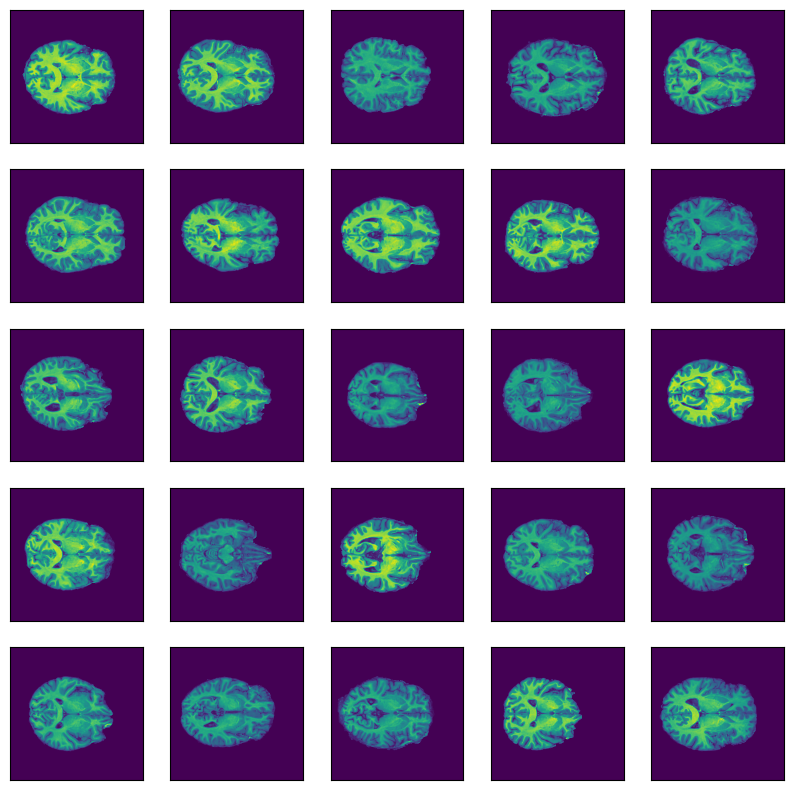

In [20]:
dataset1_x_n = np.array(dataset1_x)
dataset2_x_n = np.array(dataset2_x)
dataset1_x_n, dataset2_x_n = dataset1_x_n/255.0 , dataset2_x_n/255.0
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    # plt.imshow(dataset1_x_n[i])
    plt.imshow(dataset1_x_n[i][:,:,90])
plt.show()

In [23]:
model = models.Sequential()
model.add(layers.Conv2D(32, kernel_size=(3, 3), input_shape=(240,240,180), padding='same'))
model.add(layers.Activation('relu'))
model.add(layers.Conv2D(32, kernel_size=(3, 3), padding='same'))
model.add(layers.Activation('softmax'))
model.add(layers.MaxPooling2D(pool_size=(3, 3), padding='same'))
model.add(layers.Dropout(0.25))

model.add(layers.Conv2D(64, kernel_size=(3, 3), padding='same'))
model.add(layers.Activation('relu'))
model.add(layers.Conv2D(64, kernel_size=(3, 3), padding='same'))
model.add(layers.Activation('softmax'))
model.add(layers.MaxPooling2D(pool_size=(3, 3), padding='same'))
model.add(layers.Dropout(0.25))

model.add(layers.Flatten())
model.add(layers.Dense(512, activation='sigmoid'))
model.add(layers.Dense(128, activation='sigmoid'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(2, activation='softmax'))
model.summary()


Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_4 (Conv2D)           (None, 240, 240, 32)      51872     
                                                                 
 activation_4 (Activation)   (None, 240, 240, 32)      0         
                                                                 
 conv2d_5 (Conv2D)           (None, 240, 240, 32)      9248      
                                                                 
 activation_5 (Activation)   (None, 240, 240, 32)      0         
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 80, 80, 32)       0         
 2D)                                                             
                                                                 
 dropout_3 (Dropout)         (None, 80, 80, 32)        0         
                                                      

In [11]:
print(len(dataset2_y),len(dataset2_x))

31 31


In [12]:
# model = models.Sequential()
# model.add(layers.Conv1D(32, kernel_size=3, input_shape=(240,240), padding='same'))
# model.add(layers.Activation('relu'))
# model.add(layers.Conv1D(32, kernel_size=3, padding='same'))
# model.add(layers.Activation('relu'))
# model.add(layers.MaxPooling1D(pool_size=3, padding='same'))
# model.add(layers.Dropout(0.25))

# model.add(layers.Conv1D(64, kernel_size=3, padding='same'))
# model.add(layers.Activation('relu'))
# model.add(layers.Conv1D(64, kernel_size=3, padding='same'))
# model.add(layers.Activation('relu'))
# model.add(layers.MaxPooling1D(pool_size=3, padding='same'))
# model.add(layers.Dropout(0.25))

# model.add(layers.Flatten())
# model.add(layers.Dense(128, activation='relu'))
# model.add(layers.Dropout(0.5))
# model.add(layers.Dense(2))
# model.summary()


In [13]:
# model = models.Sequential()
# model.add(layers.Convolution1D(32, 3, 3, padding='same',
#                         input_shape=(240,240)))
# model.add(layers.Activation('relu'))
# model.add(layers.Convolution1D(32, 3, 3))
# model.add(layers.Activation('relu'))
# model.add(layers.MaxPooling1D(pool_size=2))
# model.add(layers.Dropout(0.25))

# model.add(layers.Convolution1D(64, 3, 3, padding='same'))
# model.add(layers.Activation('relu'))
# model.add(layers.Convolution1D(64, 3, 3))
# model.add(layers.Activation('relu'))
# model.add(layers.MaxPooling1D(pool_size=2))
# model.add(layers.Dropout(0.25))

# model.add(layers.Flatten())
# model.add(layers.Dense(512))
# model.add(layers.Activation('relu'))
# model.add(layers.Dropout(0.5))
# model.add(layers.Dense(nb_classes))
# model.add(layers.Activation('softmax'))

# model = models.Sequential()
# model.add(layers.Conv1D(32, kernel_size=3, input_shape=(240,240), padding='same'))
# model.add(layers.Activation('relu'))
# model.add(layers.Conv1D(32, kernel_size=3, padding='same'))
# model.add(layers.Activation('relu'))
# model.add(layers.MaxPooling1D(pool_size=2, padding='same'))
# model.add(layers.Dropout(0.25))

# model.add(layers.Conv1D(64, kernel_size=3, padding='same'))
# model.add(layers.Activation('relu'))
# model.add(layers.Conv1D(64, kernel_size=3, padding='same'))
# model.add(layers.Activation('relu'))
# model.add(layers.MaxPooling1D(pool_size=2, padding='same'))
# model.add(layers.Dropout(0.25))

# model.add(layers.Flatten())
# model.add(layers.Dense(512, activation='relu'))
# model.add(layers.Dropout(0.5))
# model.add(layers.Dense(2))
# model.summary()


In [14]:
dataset1_y_n = tf.one_hot(dataset1_y, 2)
dataset2_y_n = tf.one_hot(dataset2_y, 2)

In [15]:
print(len(dataset2_y_n),len(dataset2_x_n))

31 31


In [16]:
model.compile(loss=tf.keras.losses.categorical_crossentropy, optimizer='adam', metrics=['accuracy'])
# model.compile(loss=tf.keras.losses.categorical_crossentropy, optimizer='adam', metrics=['accuracy'])

# os.environ["tf_gpu_allocator"]="cuda_malloc_async"
# os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

history = model.fit(dataset1_x_n, dataset1_y_n, epochs=200, validation_data=(dataset2_x_n,dataset2_y_n))

Epoch 1/200
1/1 [==============================] - 18s 18s/step - loss: 1.2386 - accuracy: 0.5312 - val_loss: 0.7448 - val_accuracy: 0.4516
Epoch 2/200
1/1 [==============================] - 1s 1s/step - loss: 0.8253 - accuracy: 0.4375 - val_loss: 0.9723 - val_accuracy: 0.4516
Epoch 3/200
1/1 [==============================] - 1s 1s/step - loss: 1.0711 - accuracy: 0.4375 - val_loss: 0.8820 - val_accuracy: 0.4516
Epoch 4/200
1/1 [==============================] - 1s 1s/step - loss: 1.1448 - accuracy: 0.4688 - val_loss: 0.7245 - val_accuracy: 0.4516
Epoch 5/200
1/1 [==============================] - 1s 1s/step - loss: 0.8244 - accuracy: 0.4062 - val_loss: 0.6928 - val_accuracy: 0.5484
Epoch 6/200
1/1 [==============================] - 1s 1s/step - loss: 0.9301 - accuracy: 0.5000 - val_loss: 0.7417 - val_accuracy: 0.5484
Epoch 7/200
1/1 [==============================] - 1s 1s/step - loss: 0.8210 - accuracy: 0.4375 - val_loss: 0.7768 - val_accuracy: 0.5484
Epoch 8/200
1/1 [===============

1/1 - 0s - loss: 0.6892 - accuracy: 0.5484 - 484ms/epoch - 484ms/step


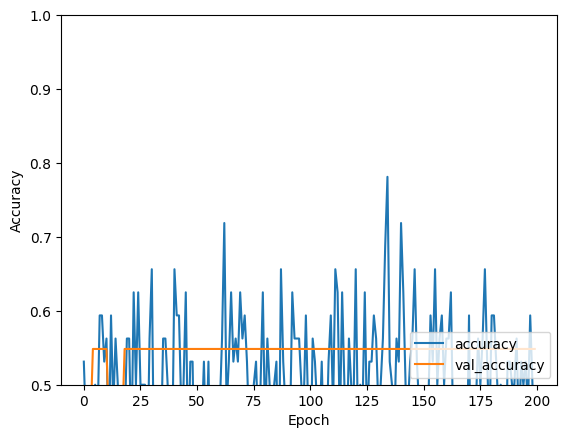

In [17]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(dataset2_x_n,  dataset2_y_n, verbose=2)

In [18]:
test_acc

0.5483871102333069